<a href="https://colab.research.google.com/github/cassiecinzori/ECON3916/blob/main/Labs/Lecture11/Dirty_Data_Forensics_and_Structural_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dirty Data Forensics and Structural Engineering

### Cassandra Cinzori

### Step 1: Environment Initialization and Data Ingestion

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt

# Step 1: Ingestion from external source
url = 'https://raw.githubusercontent.com/cassiecinzori/reference_data/refs/heads/main/messy_hr_economics.csv'
df = pd.read_csv(url)

### Step 2: Visual Forensics of Missing Data

/tmp/ipykernel_147/4009455634.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


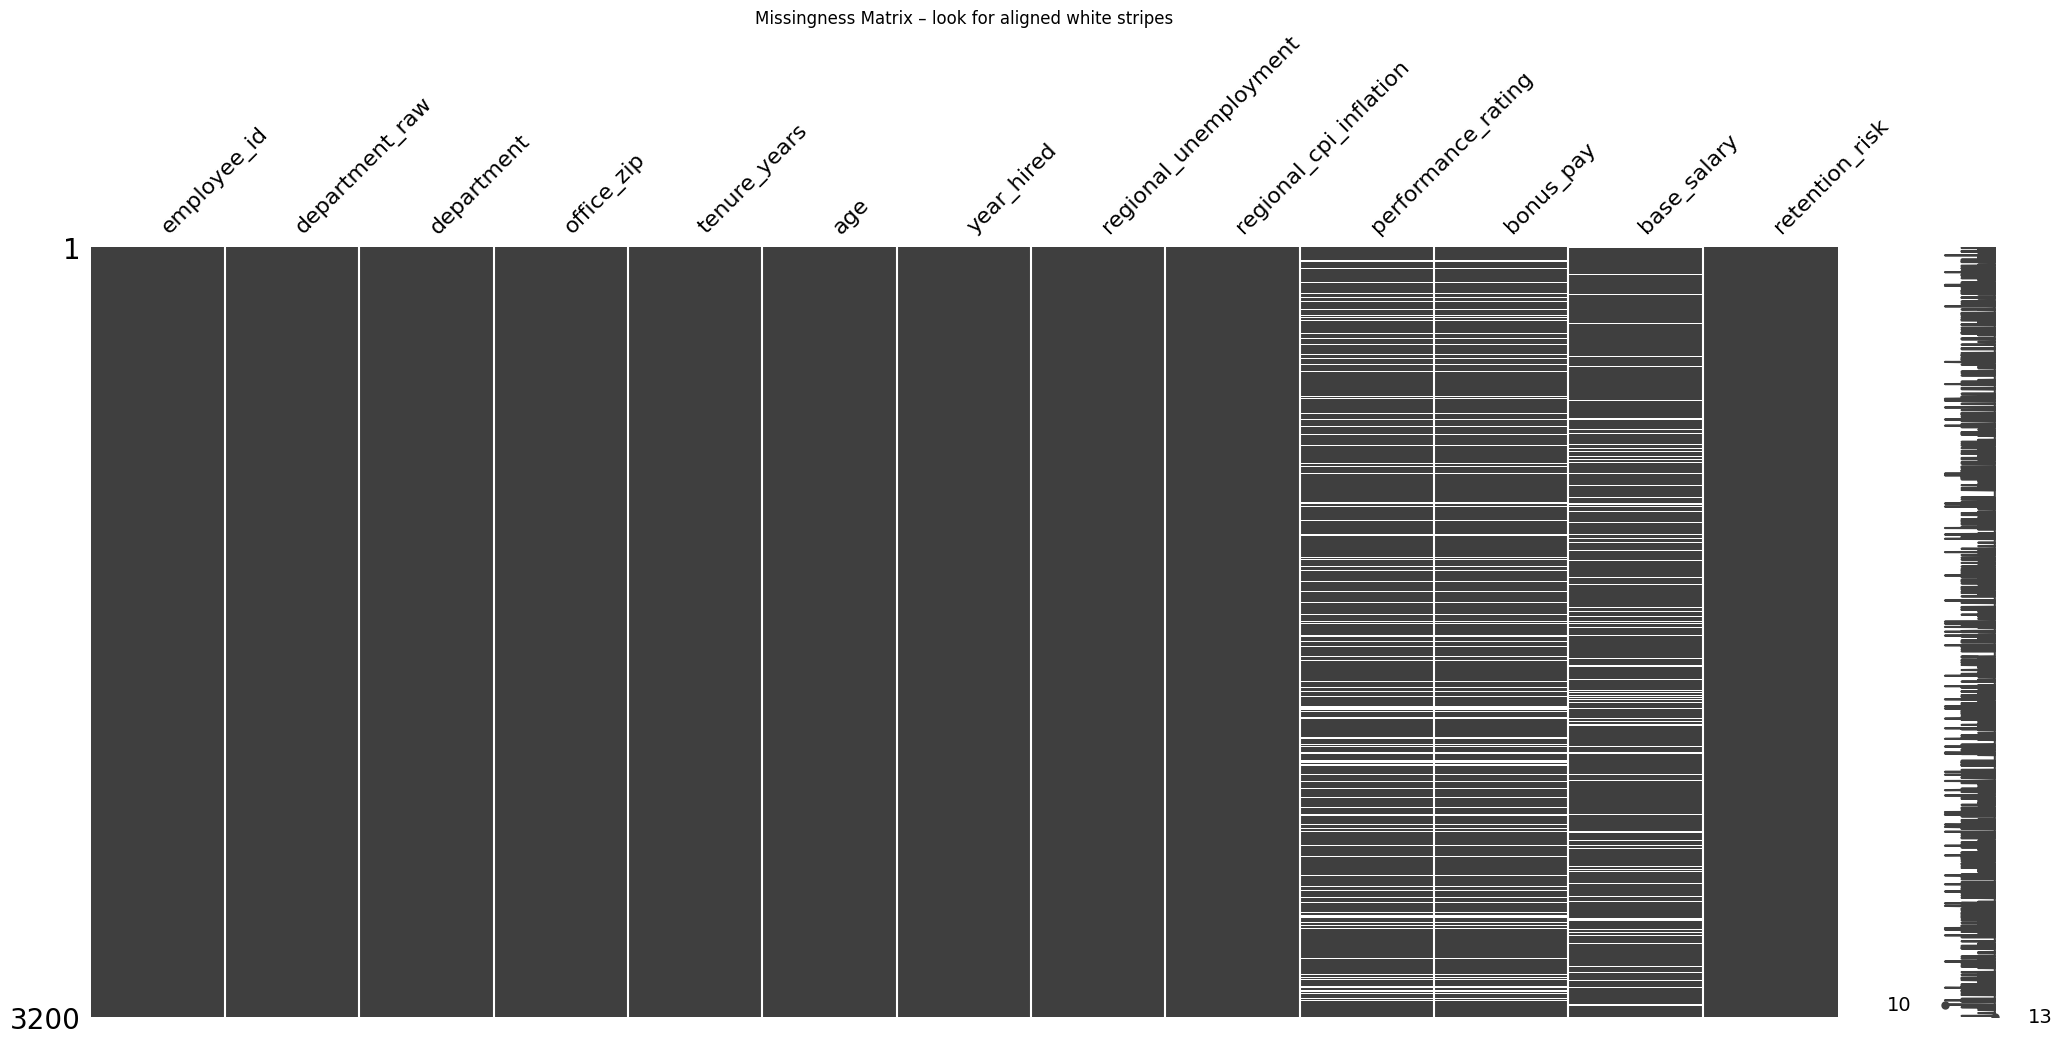

In [8]:
msno.matrix(df)
plt.title("Missingness Matrix – look for aligned white stripes")
plt.tight_layout()
plt.show()

### Step 3: Handling the Missingness via Conditional Imputation

In [9]:
df['base_salary'] = (
    df.groupby('department')['base_salary']
      .transform(lambda x: x.fillna(x.median()))
)

### Step 4: Springing the Dummy Variable Trap

In [10]:
# Step 4: The Dummy Variable Trap (Intentional Failure)
dummies_trap = pd.get_dummies(df['department']).astype(int)

X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)
X_trap = sm.add_constant(X_trap)
y = df['base_salary']

model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:04:18   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.765e+04    244.020    236.246   

### Step 5: Escaping the Trap and Executing Advanced Encoding

In [11]:
dummies_safe = pd.get_dummies(df['department'], drop_first=True).astype(int)

X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)

model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())


encoder = ce.TargetEncoder(cols=['office_zip'])
df['zip_encoded'] = encoder.fit_transform(df['office_zip'], df['base_salary'])

print(df[['office_zip', 'zip_encoded']].head(10))

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:04:21   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         9.527e+04    372.412    255.807   

### AI Expansion

In [15]:
# AI Expansion: Interactive Visual Forensics Dashboard (Colab-compatible)
# Uses ipywidgets instead of Streamlit — runs natively in Colab/Jupyter.
#
# ipywidgets provides interactive UI elements (dropdowns, buttons, output areas)
# that render inline in the notebook. No separate server needed.
# The dashboard state (imputed df) is held in a plain Python dict called
# `state`, which persists across widget callbacks for the lifetime of the cell.

import ipywidgets as widgets
from IPython.display import display, clear_output
import missingno as msno
import matplotlib.pyplot as plt
import pandas as pd

# state dict holds the working DataFrame so imputation changes persist
# across button clicks without re-running the whole cell
state = {'df': df.copy()}

# ------------------------------------------------------------------
# SECTION 1: Null audit output (renders immediately on run)
# ------------------------------------------------------------------
print("=" * 50)
print("VISUAL FORENSICS DASHBOARD")
print("=" * 50)

print("\n📋 Data Preview (first 5 rows):")
display(state['df'].head())

print("\n🔍 Null Value Counts:")
null_counts = state['df'].isnull().sum().rename("missing").to_frame()
null_counts["% missing"] = (null_counts["missing"] / len(state['df']) * 100).round(2)
display(null_counts[null_counts["missing"] > 0])

# ------------------------------------------------------------------
# SECTION 2: Missingness matrix button
# ------------------------------------------------------------------
btn_matrix = widgets.Button(
    description="Show Missingness Matrix",
    button_style="info",
    layout=widgets.Layout(width="220px")
)
matrix_out = widgets.Output()

def show_matrix(_):
    # widgets.Output() captures matplotlib figures and displays them
    # inline — without this, plt.show() would render outside the widget
    with matrix_out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 4))
        msno.matrix(state['df'], ax=ax, sparkline=False)
        ax.set_title("Missingness Matrix – aligned white stripes indicate MAR")
        plt.tight_layout()
        plt.show()

btn_matrix.on_click(show_matrix)
display(widgets.VBox([btn_matrix, matrix_out]))

# ------------------------------------------------------------------
# SECTION 3: Conditional imputation controls
# ------------------------------------------------------------------
print("\n⚙️ Conditional Median Imputation")

num_cols = state['df'].select_dtypes(include="number").columns.tolist()
cat_cols = state['df'].select_dtypes(include="object").columns.tolist()

# Dropdowns let the user select which column to impute and which to group by
dd_target = widgets.Dropdown(options=num_cols, description="Impute:")
dd_group  = widgets.Dropdown(options=cat_cols, description="Group by:")
btn_impute = widgets.Button(
    description="Run Imputation",
    button_style="success",
    layout=widgets.Layout(width="160px")
)
impute_out = widgets.Output()

def run_imputation(_):
    with impute_out:
        clear_output(wait=True)
        target = dd_target.value
        group  = dd_group.value
        before = state['df'][target].isnull().sum()

        # Update the shared state dict so the imputed df persists
        state['df'][target] = (
            state['df']
              .groupby(group)[target]
              .transform(lambda x: x.fillna(x.median()))
        )
        after = state['df'][target].isnull().sum()
        print(f"✅ Imputed {before - after} missing values in '{target}' "
              f"using per-'{group}' medians. Remaining nulls: {after}.")
        display(state['df'].head(10))

btn_impute.on_click(run_imputation)
display(widgets.VBox([
    widgets.HBox([dd_target, dd_group]),
    btn_impute,
    impute_out
]))

VISUAL FORENSICS DASHBOARD

📋 Data Preview (first 5 rows):


,employee_id,department_raw,department,office_zip,tenure_years,age,year_hired,regional_unemployment,regional_cpi_inflation,performance_rating,bonus_pay,base_salary,retention_risk,zip_encoded
0,E100000,Sls,Sales,91586,2.3,27,2024,4.30,3.54,3.0,3571.89,64113.01,0.275,96850.469864
1,E100001,ENG.,Engineering,70260,2.2,38,2024,3.52,3.95,4.5,9351.25,113883.39,0.196,96921.404305
2,E100002,Sales,Sales,33731,1.2,44,2025,4.38,0.70,2.5,3046.72,80097.17,0.333,92833.861323
3,E100003,SLS.,Sales,62903,3.2,31,2023,6.59,3.10,NaN,NaN,58762.73,0.222,93624.380293
4,E100004,ENG.,Engineering,85512,7.6,40,2019,6.33,2.99,3.5,8669.21,108171.29,0.189,95127.965538



🔍 Null Value Counts:


,missing,% missing
performance_rating,452,14.12
bonus_pay,452,14.12



⚙️ Conditional Median Imputation
